In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle
from scipy.signal import fftconvolve
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography
import numpy as np
from scipy.signal import fftconvolve
from scipy.ndimage import maximum_filter, label, find_objects
from scipy.ndimage import shift
from scipy.ndimage import zoom
def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

from quantem.core.utils.imaging_utils import detect_bragg_disks, bragg_disks_to_masks

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase

def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba




quantEM version: 0.1.8


In [ ]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 6
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=True,
)
atoms *= (26,15,1)
# atoms *= (26,15,1)
# atoms *= (38,22,1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

In [ ]:
pot_gpts = 2048
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

potential[0].show(
    cbar=True,
    figsize=(6,6)
);

potential.show(
    cbar=True,
    figsize=(6,6),
    explode=True
);

In [ ]:
energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 28

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)




In [ ]:
pot_gpts = 512
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 6

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)
start = [0,0]
end = [potential.extent[0],potential.extent[1]]
print(end)
gpts = 64

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=True
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

fig,ax = plt.subplots()
abtem.show_atoms(atoms,ax=ax)
grid_scan.add_to_plot(ax)
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()


measurement_cropped = measurement.crop(gpts=(256,256))


In [ ]:
dose = 1e15

intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dset_6 = dataset_noisy

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

In [ ]:
pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()


# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

In [ ]:

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}


scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
    # "object": {
    #     # "gaussian_sigma": 2.0,      # was "gaussian_filter_sigma" + "gaussian_filter"
    # },
}


ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//64,
    device="cuda:0",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
    disk_phase='disk_phase',
    rng=0
)

ptycho_pix_reconstruct_6.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct_6.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);


In [ ]:
norm_fft = NormalizationConfig(
    interval_type='manual',
    stretch_type='power',
    power=0.5
)

phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)
print(phase.shape)
# Build a 2D Hann window
H, W = phase.shape
window = np.outer(hann(H), hann(W))

phase_windowed = phase * window

fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))


fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))
fft_mag[H//2, W//2] = 0

# Convolve with small disk — increase radius for more spreading
kernel = disk(2).astype(float)
kernel /= kernel.sum()
fft_mag = convolve(fft_mag, kernel)


rgba_main = real_array_to_rgba(phase)
rgba_fft = real_array_to_rgba(fft_mag, cmap='magma')

# Compose the final figure
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgba_main,interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling = ptycho_pix_reconstruct_6.sampling[1],
#     units = 'A',
#     length = 10,
# )

# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     ptycho_pix_reconstruct_6.obj[0].shape[1],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+2,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=26
# )

inset_ax = fig.add_axes([0.60, 0.02, 0.38, 0.38])
inset_ax.imshow(rgba_fft)
inset_ax.axis('off')

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_6.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     inset_ax,
#     dset_6.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+1,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=16
# )


In [ ]:


print(potential.shape)
print(rgba_main.shape)

potential_sub1 = zoom(potential.array[0::3].sum(0), 0.5, order=3)
potential_sub2 = zoom(potential.array[1::3].sum(0), 0.5, order=3)
potential_sub3 = zoom(potential.array[2::3].sum(0), 0.5, order=3)

print(potential_sub1.shape)
fig, ax = plt.subplots(figsize=(12, 12),)
# ax.imshow(rgba_main,interpolation=None)
ax.imshow(potential_sub1, alpha=0.25)
# ax.imshow(potential_sub2, alpha=0.25)
# ax.imshow(potential_sub3, alpha=0.25)
# ax.imshow(potential_sub1, alpha=1)
# ax.imshow(potential_sub2, alpha=1)
# ax.imshow(potential_sub3, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)

ax.axis('off')


In [ ]:
potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)
show_2d(potential_sub)
fig, ax = plt.subplots(figsize=(8, 8),)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)
ax.axis('off')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12),)
# ax.imshow(rgba_main,interpolation=None)
# ax.imshow(potential_sub, alpha=0.25)
# ax.imshow(potential_sub2, alpha=0.25)
# ax.imshow(potential_sub3, alpha=0.25)
# ax.imshow(potential_sub1, alpha=1)
# ax.imshow(potential_sub2, alpha=1)
# ax.imshow(potential_sub3, alpha=1)
ax.imshow(rgba_main,interpolation=None, alpha=0.25)

ax.axis('off')

In [ ]:
print(potential_sub.shape)
rgba_main.shape

In [ ]:

def to_grayscale(rgba):
    # if it's literally grayscale stored as RGBA, R channel alone is fine
    # otherwise use luminance weighting
    rgb = rgba[..., :3]
    alpha = rgba[..., 3]
    gray = rgb @ np.array([0.2989, 0.5870, 0.1140])
    return gray, alpha

main_gray, main_alpha = to_grayscale(rgba_main)

# normalize both (zero mean, unit norm) so correlation is scale-invariant
def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

a = normalize(potential_sub)
b = normalize(main_gray)
c = normalize(phase)
fig, ax = plt.subplots(figsize=(12, 12),)

ax.imshow(a)
# ax.imshow(potential_sub2, alpha=0.25)
# ax.imshow(potential_sub3, alpha=0.25)
# ax.imshow(potential_sub1, alpha=1)
# ax.imshow(potential_sub2, alpha=1)
# ax.imshow(potential_sub3, alpha=1)
# ax.imshow(rgba_main,interpolation=None, alpha=0.25)

ax.axis('off')
fig, ax = plt.subplots(figsize=(12, 12),)

ax.imshow(c)
# ax.imshow(potential_sub2, alpha=0.25)
# ax.imshow(potential_sub3, alpha=0.25)
# ax.imshow(potential_sub1, alpha=1)
# ax.imshow(potential_sub2, alpha=1)
# ax.imshow(potential_sub3, alpha=1)
# ax.imshow(rgba_main,interpolation=None, alpha=0.25)

ax.axis('off')

# full 2D cross-correlation via FFT (much faster than direct convolution at 256x256)
xcorr = fftconvolve(a, b[::-1, ::-1], mode='full')
xcorr = fftconvolve(a, c, mode='full')

# location and value of peak correlation
peak_idx = np.unravel_index(np.argmax(xcorr), xcorr.shape)
peak_val = xcorr[peak_idx]

# convert peak location to shift relative to zero-shift center
center = np.array(xcorr.shape) // 2
shift = np.array(peak_idx) - center
print("peak correlation:", peak_val, "at shift (row, col):", shift)

In [ ]:


def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    return img / np.linalg.norm(img)

def to_grayscale(rgba):
    return rgba[..., :3] @ np.array([0.2989, 0.5870, 0.1140])

a = normalize(potential_sub)
b = normalize(to_grayscale(rgba_main))
c= normalize(phase)
xcorr = fftconvolve(a, b[::-1, ::-1], mode='full')
xcorr = fftconvolve(a, c, mode='full')

N = a.shape[0]
center = N - 1  # zero-lag index in each dimension

# --- step 1: find local maxima on the discrete grid ---
neighborhood_size = 5  # adjust based on expected peak spacing/width
local_max = (xcorr == maximum_filter(xcorr, size=neighborhood_size))


# threshold to discard noise peaks (keep only strong ones)
threshold = 0.3 * xcorr.max()
peak_mask = local_max & (xcorr > threshold)

peak_coords = np.argwhere(peak_mask)
print(f"found {len(peak_coords)} candidate peaks")

In [ ]:
def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

results = []
for (r, c) in peak_coords:
    # skip edge pixels where parabolic interpolation would go out of bounds
    if r == 0 or r == xcorr.shape[0]-1 or c == 0 or c == xcorr.shape[1]-1:
        continue
    r_sub, c_sub = parabolic_subpixel_peak(xcorr, r, c)
    row_lag = r_sub - center
    col_lag = c_sub - center
    distance = np.hypot(row_lag, col_lag)
    angle_deg = np.degrees(np.arctan2(row_lag, col_lag))
    value = xcorr[r, c]
    results.append({
        'row_lag': row_lag,
        'col_lag': col_lag,
        'distance_px': distance,
        'angle_deg': angle_deg,
        'peak_value': value
    })

# sort by distance from zero-lag
results.sort(key=lambda x: x['distance_px'])

# for res in results:
#     print(f"lag=({res['row_lag']:.3f}, {res['col_lag']:.3f})  "
#           f"dist={res['distance_px']:.3f}px  angle={res['angle_deg']:.1f}°  "
#           f"value={res['peak_value']:.4f}")

In [ ]:

nonzero_results = [r for r in results if r['distance_px'] > 1e-3]
distances = np.array([r['distance_px'] for r in nonzero_results])

# --- nearest-neighbor spacing between peaks (lattice periodicity) ---
# sort all peak positions, then for each peak find distance to its nearest other peak
positions = np.array([(r['row_lag'], r['col_lag']) for r in results])  # include (0,0) here

nn_distances = []
for i, pos in enumerate(positions):
    diffs = positions - pos
    dists = np.hypot(diffs[:, 0], diffs[:, 1])
    dists[i] = np.inf  # exclude self
    nn_distances.append(dists.min())

nn_distances = np.array(nn_distances)
avg_nn_spacing = nn_distances.mean()
std_nn_spacing = nn_distances.std()

print(f"average nearest-neighbor peak spacing: {avg_nn_spacing:.4f} px")
print(f"std of nearest-neighbor peak spacing:  {std_nn_spacing:.4f} px")

# --- offset: distance from (0,0) to the closest peak ---
closest_idx = np.argmin(distances)
closest_peak = nonzero_results[closest_idx]
offset_distance = closest_peak['distance_px']

print(f"\noffset of nearest peak from (0,0): {offset_distance:.4f} px")
print(f"  lag (row, col): ({closest_peak['row_lag']:.4f}, {closest_peak['col_lag']:.4f})")
print(f"  peak value: {closest_peak['peak_value']:.4f}")

# normalized offset, as a fraction of the lattice spacing — useful single number
# for "how misaligned are the two images relative to one lattice period"
fractional_offset = offset_distance / avg_nn_spacing
print(f"\noffset as fraction of lattice spacing: {fractional_offset:.4f}")

average nearest-neighbor peak spacing: 5.6500 px
std of nearest-neighbor peak spacing:  0.1068 px

offset of nearest peak from (0,0): 0.4625 px
  lag (row, col): (-0.3138, -0.3398)
  peak value: 0.6656

offset as fraction of lattice spacing: 0.0819

average nearest-neighbor peak spacing: 3.1606 px
std of nearest-neighbor peak spacing:  0.9041 px

offset of nearest peak from (0,0): 1.4798 px
  lag (row, col): (-0.2209, 1.4633)
  peak value: 0.3776

offset as fraction of lattice spacing: 0.4682

average nearest-neighbor peak spacing: 5.5711 px
std of nearest-neighbor peak spacing:  0.0555 px

offset of nearest peak from (0,0): 2.2053 px
  lag (row, col): (-1.8041, -1.2682)
  peak value: 0.3654

offset as fraction of lattice spacing: 0.3958

## infinite 6mrad


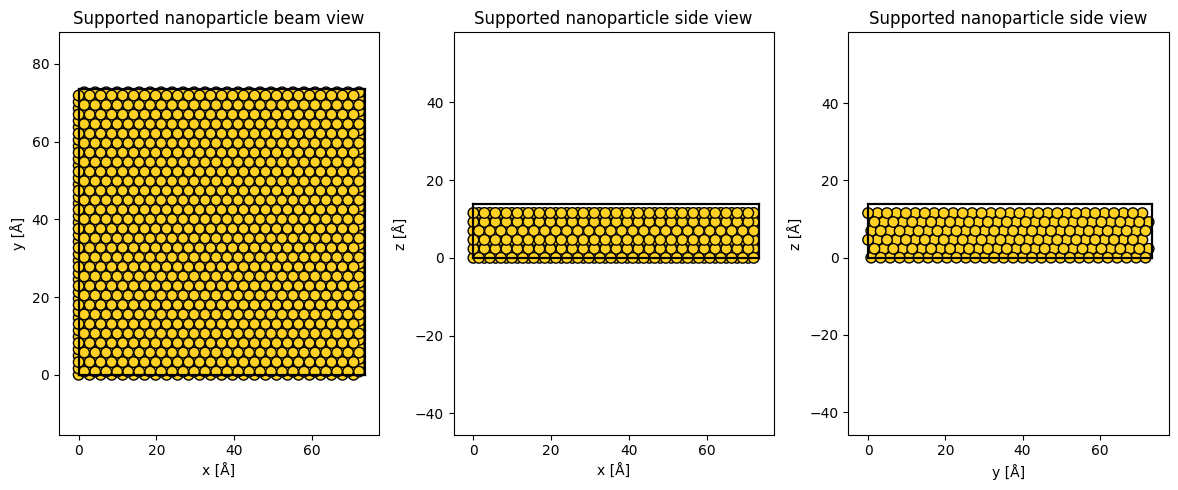

In [3]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 6
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=True,
)
atoms *= (26,15,1)
# atoms *= (26,15,1)
# atoms *= (38,22,1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

[73.53910524340095, 73.48469228349533]


tasks:   0%|          | 0/82 [00:00<?, ?it/s]

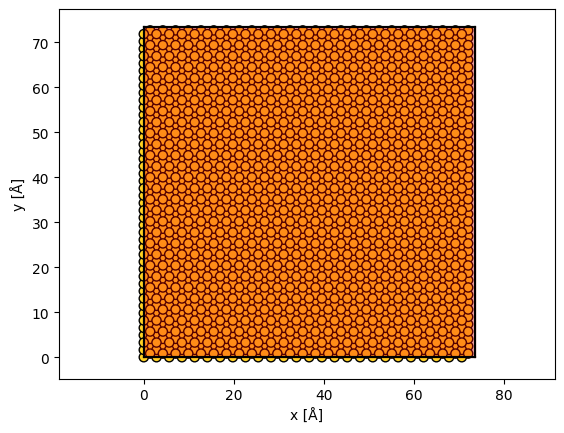

In [4]:
pot_gpts = 512
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 6

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)
start = [0,0]
end = [potential.extent[0],potential.extent[1]]
print(end)
gpts = 64

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=True
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

fig,ax = plt.subplots()
abtem.show_atoms(atoms,ax=ax)
grid_scan.add_to_plot(ax)
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()


measurement_cropped = measurement.crop(gpts=(256,256))


In [5]:
dose = 1e15

intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dset_6 = dataset_noisy

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(5.663001616765536)]
[np.float64(0.010468024058817542)]
[np.float64(2.788667906802671)]


...

[np.float64(5.663001616765536), np.float64(5.649441766857394), np.float64(5.654858611813681), np.float64(5.64288297291199), np.float64(5.6402054221187745), np.float64(5.542533679253318), np.float64(5.6608225322048575), np.float64(5.6538521097929895), np.float64(5.655070032315088), np.float64(5.6525899580786065), np.float64(5.647128858119929), np.float64(5.63940357792263), np.float64(5.666867573043103), np.float64(5.647076113909568), np.float64(5.663504506464697), np.float64(5.651993592079916), np.float64(5.656066370555875), np.float64(5.632913685599197), np.float64(5.665087188192333), np.float64(5.664900944838224), np.float64(5.63065712256729), np.float64(5.653354766862111), np.float64(5.6515664339478855), np.float64(5.664344605806107), np.float64(5.661646924124961), np.float64(5.655035586259418), np.float64(5.651521417064892), np.float64(5.612383926655939)]
[np.float64(0.010468024058817542), np.float64(0.026516780107113957), np.float64(0.009426377195697873), np.float64(0.0213993072565

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(5.663001616765536), np.float64(5.649441766857394), np.float64(5.654858611813681), np.float64(5.64288297291199), np.float64(5.6402054221187745), np.float64(5.542533679253318), np.float64(5.6608225322048575), np.float64(5.6538521097929895), np.float64(5.655070032315088), np.float64(5.6525899580786065), np.float64(5.647128858119929), np.float64(5.63940357792263), np.float64(5.666867573043103), np.float64(5.647076113909568), np.float64(5.663504506464697), np.float64(5.651993592079916), np.float64(5.656066370555875), np.float64(5.632913685599197), np.float64(5.665087188192333), np.float64(5.664900944838224), np.float64(5.63065712256729), np.float64(5.653354766862111), np.float64(5.6515664339478855), np.float64(5.664344605806107), np.float64(5.661646924124961), np.float64(5.655035586259418), np.float64(5.651521417064892), np.float64(5.612383926655939), np.float64(5.660486837834003)]
[np.float64(0.010468024058817542), np.float64(0.026516780107113957), np.float64(0.0094263771956978

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(5.663001616765536), np.float64(5.649441766857394), np.float64(5.654858611813681), np.float64(5.64288297291199), np.float64(5.6402054221187745), np.float64(5.542533679253318), np.float64(5.6608225322048575), np.float64(5.6538521097929895), np.float64(5.655070032315088), np.float64(5.6525899580786065), np.float64(5.647128858119929), np.float64(5.63940357792263), np.float64(5.666867573043103), np.float64(5.647076113909568), np.float64(5.663504506464697), np.float64(5.651993592079916), np.float64(5.656066370555875), np.float64(5.632913685599197), np.float64(5.665087188192333), np.float64(5.664900944838224), np.float64(5.63065712256729), np.float64(5.653354766862111), np.float64(5.6515664339478855), np.float64(5.664344605806107), np.float64(5.661646924124961), np.float64(5.655035586259418), np.float64(5.651521417064892), np.float64(5.612383926655939), np.float64(5.660486837834003), np.float64(5.650292710771999)]
[np.float64(0.010468024058817542), np.float64(0.026516780107113957)

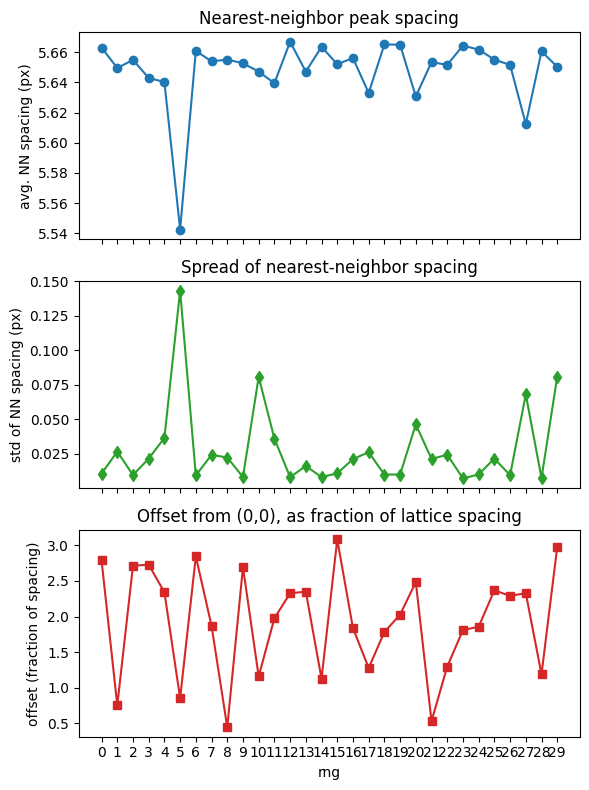

In [6]:

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
}

avg_nearest_neighbour_spacing_1 = []
avg_nearest_neighbour_spacing_m1 = []
std_nearest_neighbour_spacing_1 = []
std_nearest_neighbour_spacing_m1 = []
offset_fraction_lattice_spacing_1 = []
offset_fraction_lattice_spacing_m1 = []
std_nearest_neighbour_spacing = []
offset_fraction_lattice_spacing = []
avg_nearest_neighbour_spacing = []

pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()



# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

rng = range(30)
potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)

for i in rng:
    

    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//64,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    rng=i
    )
    for sign in [1,-1]:
        phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)
        a = normalize(potential_sub)
        c = normalize(sign * phase)
        xcorr = fftconvolve(a, c, mode='full')
        N = a.shape[0]
        center = N - 1  # zero-lag index in each dimension

        # --- step 1: find local maxima on the discrete grid ---
        neighborhood_size = 5  # adjust based on expected peak spacing/width
        local_max = (xcorr == maximum_filter(xcorr, size=neighborhood_size))

        # threshold to discard noise peaks (keep only strong ones)
        threshold = 0.3 * xcorr.max()
        peak_mask = local_max & (xcorr > threshold)

        peak_coords = np.argwhere(peak_mask)

        results = []
        for (r, c) in peak_coords:
            # skip edge pixels where parabolic interpolation would go out of bounds
            if r == 0 or r == xcorr.shape[0]-1 or c == 0 or c == xcorr.shape[1]-1:
                continue
            r_sub, c_sub = parabolic_subpixel_peak(xcorr, r, c)
            row_lag = r_sub - center
            col_lag = c_sub - center
            distance = np.hypot(row_lag, col_lag)
            angle_deg = np.degrees(np.arctan2(row_lag, col_lag))
            value = xcorr[r, c]
            results.append({
                'row_lag': row_lag,
                'col_lag': col_lag,
                'distance_px': distance,
                'angle_deg': angle_deg,
                'peak_value': value
            })

        # sort by distance from zero-lag
        results.sort(key=lambda x: x['distance_px'])

            
        nonzero_results = [r for r in results if r['distance_px'] > 1e-3]
        distances = np.array([r['distance_px'] for r in nonzero_results])

        # --- nearest-neighbor spacing between peaks (lattice periodicity) ---
        # sort all peak positions, then for each peak find distance to its nearest other peak
        positions = np.array([(r['row_lag'], r['col_lag']) for r in results])  # include (0,0) here

        nn_distances = []
        for i, pos in enumerate(positions):
            diffs = positions - pos
            dists = np.hypot(diffs[:, 0], diffs[:, 1])
            dists[i] = np.inf  # exclude self
            nn_distances.append(dists.min())

        nn_distances = np.array(nn_distances)
        avg_nn_spacing = nn_distances.mean()
        std_nn_spacing = nn_distances.std()



        # --- offset: distance from (0,0) to the closest peak ---
        closest_idx = np.argmin(distances)
        closest_peak = nonzero_results[closest_idx]
        offset_distance = closest_peak['distance_px']



        # normalized offset, as a fraction of the lattice spacing — useful single number
        # for "how misaligned are the two images relative to one lattice period"
        fractional_offset = offset_distance / avg_nn_spacing
        if sign == 1:
            avg_nearest_neighbour_spacing_1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_1.append(offset_distance)
        if sign == -1:
            avg_nearest_neighbour_spacing_m1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_m1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_m1.append(offset_distance)
    if std_nearest_neighbour_spacing_1[-1] < std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_1[-1])
    if std_nearest_neighbour_spacing_1[-1] > std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_m1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_m1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_m1[-1])


    print(avg_nearest_neighbour_spacing)
    print(std_nearest_neighbour_spacing)
    print(offset_fraction_lattice_spacing)




fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(rng, avg_nearest_neighbour_spacing, 'o-', color='tab:blue')
axes[0].set_ylabel('avg. NN spacing (px)')
axes[0].set_title('Nearest-neighbor peak spacing')

axes[1].plot(rng, std_nearest_neighbour_spacing, 'd-', color='tab:green')
axes[1].set_ylabel('std of NN spacing (px)')
axes[1].set_title('Spread of nearest-neighbor spacing')

axes[2].plot(rng, offset_fraction_lattice_spacing, 's-', color='tab:red')
axes[2].set_ylabel('offset (fraction of spacing)')
axes[2].set_xlabel('rng')
axes[2].set_title('Offset from (0,0), as fraction of lattice spacing')
axes[2].set_xticks(rng)

plt.tight_layout()
plt.show()


## infinite 28 mrad

[73.53910524340095, 73.48469228349533]


tasks:   0%|          | 0/82 [00:00<?, ?it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


...

[np.float64(5.644604040721737), np.float64(5.644831405490052), np.float64(5.643448551013581), np.float64(5.6435971200061985), np.float64(5.643680851963258), np.float64(5.644854678449814), np.float64(5.645096778895653), np.float64(5.644657747781705), np.float64(5.645054061224233), np.float64(5.643433134134116), np.float64(5.644814444276974), np.float64(5.645022751242442), np.float64(5.645156489803083), np.float64(5.644914252256095), np.float64(5.644759828829879), np.float64(5.644874886034689), np.float64(5.644868961471357), np.float64(5.645110486244156), np.float64(5.645161750354314), np.float64(5.644762259250253), np.float64(5.646155655859128), np.float64(5.645103187852718), np.float64(5.644653787022604), np.float64(5.645000445002475), np.float64(5.644993163642023), np.float64(5.645041072098137), np.float64(5.645107303297427), np.float64(5.645103869780285)]
[np.float64(0.08346294603335758), np.float64(0.0833264542941799), np.float64(0.03478598546566646), np.float64(0.034773496010710996

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(5.644604040721737), np.float64(5.644831405490052), np.float64(5.643448551013581), np.float64(5.6435971200061985), np.float64(5.643680851963258), np.float64(5.644854678449814), np.float64(5.645096778895653), np.float64(5.644657747781705), np.float64(5.645054061224233), np.float64(5.643433134134116), np.float64(5.644814444276974), np.float64(5.645022751242442), np.float64(5.645156489803083), np.float64(5.644914252256095), np.float64(5.644759828829879), np.float64(5.644874886034689), np.float64(5.644868961471357), np.float64(5.645110486244156), np.float64(5.645161750354314), np.float64(5.644762259250253), np.float64(5.646155655859128), np.float64(5.645103187852718), np.float64(5.644653787022604), np.float64(5.645000445002475), np.float64(5.644993163642023), np.float64(5.645041072098137), np.float64(5.645107303297427), np.float64(5.645103869780285), np.float64(5.643740013227128)]
[np.float64(0.08346294603335758), np.float64(0.0833264542941799), np.float64(0.03478598546566646), 

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(5.644604040721737), np.float64(5.644831405490052), np.float64(5.643448551013581), np.float64(5.6435971200061985), np.float64(5.643680851963258), np.float64(5.644854678449814), np.float64(5.645096778895653), np.float64(5.644657747781705), np.float64(5.645054061224233), np.float64(5.643433134134116), np.float64(5.644814444276974), np.float64(5.645022751242442), np.float64(5.645156489803083), np.float64(5.644914252256095), np.float64(5.644759828829879), np.float64(5.644874886034689), np.float64(5.644868961471357), np.float64(5.645110486244156), np.float64(5.645161750354314), np.float64(5.644762259250253), np.float64(5.646155655859128), np.float64(5.645103187852718), np.float64(5.644653787022604), np.float64(5.645000445002475), np.float64(5.644993163642023), np.float64(5.645041072098137), np.float64(5.645107303297427), np.float64(5.645103869780285), np.float64(5.643740013227128), np.float64(5.6447934326235085)]
[np.float64(0.08346294603335758), np.float64(0.0833264542941799), n

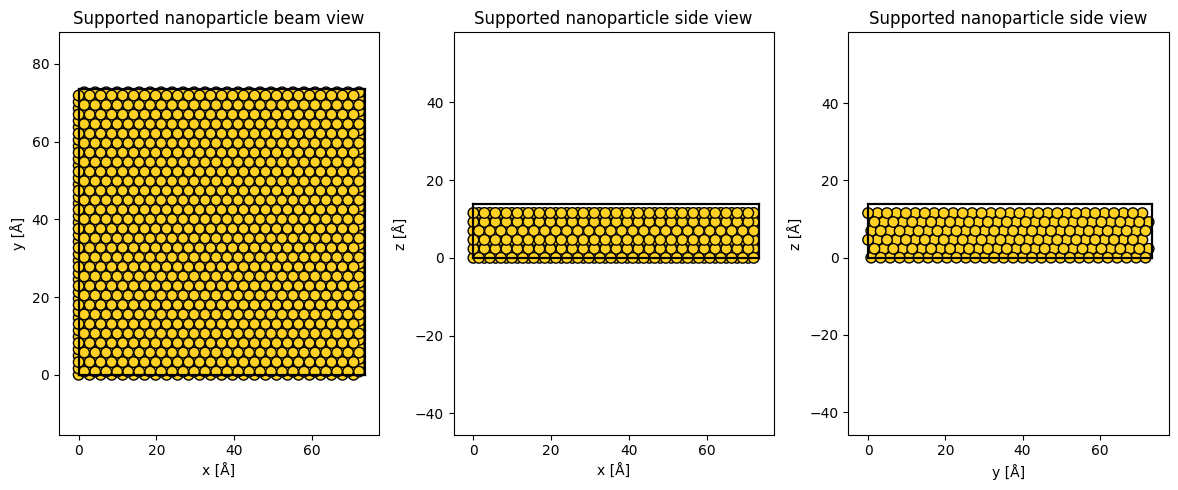

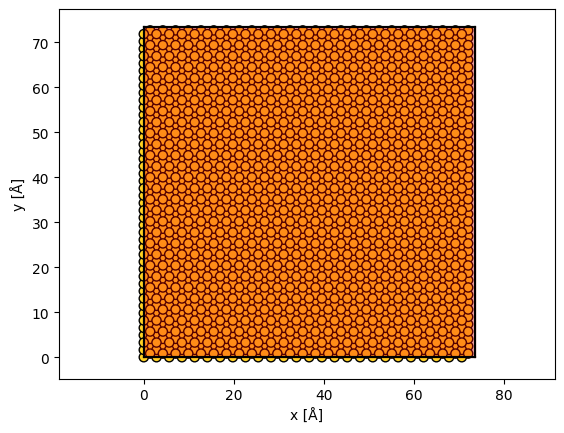

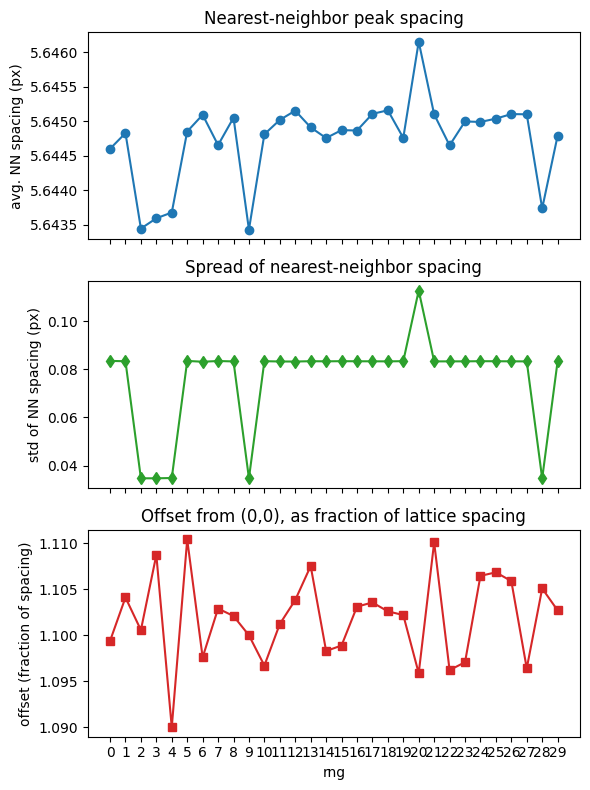

In [7]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 6
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=True,
)
atoms *= (26,15,1)
# atoms *= (26,15,1)
# atoms *= (38,22,1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();
pot_gpts = 512
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 28

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)
start = [0,0]
end = [potential.extent[0],potential.extent[1]]
print(end)
gpts = 64

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=True
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

fig,ax = plt.subplots()
abtem.show_atoms(atoms,ax=ax)
grid_scan.add_to_plot(ax)
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()


measurement_cropped = measurement.crop(gpts=(256,256))

dose = 1e15

intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dset_6 = dataset_noisy

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
}

avg_nearest_neighbour_spacing_1 = []
avg_nearest_neighbour_spacing_m1 = []
std_nearest_neighbour_spacing_1 = []
std_nearest_neighbour_spacing_m1 = []
offset_fraction_lattice_spacing_1 = []
offset_fraction_lattice_spacing_m1 = []
std_nearest_neighbour_spacing = []
offset_fraction_lattice_spacing = []
avg_nearest_neighbour_spacing = []

pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()



# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

rng = range(30)
potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)

for i in rng:
    

    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//64,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    rng=i
    )
    for sign in [1,-1]:
        phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)
        a = normalize(potential_sub)
        c = normalize(sign * phase)
        xcorr = fftconvolve(a, c, mode='full')
        N = a.shape[0]
        center = N - 1  # zero-lag index in each dimension

        # --- step 1: find local maxima on the discrete grid ---
        neighborhood_size = 5  # adjust based on expected peak spacing/width
        local_max = (xcorr == maximum_filter(xcorr, size=neighborhood_size))

        # threshold to discard noise peaks (keep only strong ones)
        threshold = 0.3 * xcorr.max()
        peak_mask = local_max & (xcorr > threshold)

        peak_coords = np.argwhere(peak_mask)

        results = []
        for (r, c) in peak_coords:
            # skip edge pixels where parabolic interpolation would go out of bounds
            if r == 0 or r == xcorr.shape[0]-1 or c == 0 or c == xcorr.shape[1]-1:
                continue
            r_sub, c_sub = parabolic_subpixel_peak(xcorr, r, c)
            row_lag = r_sub - center
            col_lag = c_sub - center
            distance = np.hypot(row_lag, col_lag)
            angle_deg = np.degrees(np.arctan2(row_lag, col_lag))
            value = xcorr[r, c]
            results.append({
                'row_lag': row_lag,
                'col_lag': col_lag,
                'distance_px': distance,
                'angle_deg': angle_deg,
                'peak_value': value
            })

        # sort by distance from zero-lag
        results.sort(key=lambda x: x['distance_px'])

            
        nonzero_results = [r for r in results if r['distance_px'] > 1e-3]
        distances = np.array([r['distance_px'] for r in nonzero_results])

        # --- nearest-neighbor spacing between peaks (lattice periodicity) ---
        # sort all peak positions, then for each peak find distance to its nearest other peak
        positions = np.array([(r['row_lag'], r['col_lag']) for r in results])  # include (0,0) here

        nn_distances = []
        for i, pos in enumerate(positions):
            diffs = positions - pos
            dists = np.hypot(diffs[:, 0], diffs[:, 1])
            dists[i] = np.inf  # exclude self
            nn_distances.append(dists.min())

        nn_distances = np.array(nn_distances)
        avg_nn_spacing = nn_distances.mean()
        std_nn_spacing = nn_distances.std()



        # --- offset: distance from (0,0) to the closest peak ---
        closest_idx = np.argmin(distances)
        closest_peak = nonzero_results[closest_idx]
        offset_distance = closest_peak['distance_px']



        # normalized offset, as a fraction of the lattice spacing — useful single number
        # for "how misaligned are the two images relative to one lattice period"
        fractional_offset = offset_distance / avg_nn_spacing
        if sign == 1:
            avg_nearest_neighbour_spacing_1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_1.append(offset_distance)
        if sign == -1:
            avg_nearest_neighbour_spacing_m1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_m1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_m1.append(offset_distance)
    if std_nearest_neighbour_spacing_1[-1] < std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_1[-1])
    if std_nearest_neighbour_spacing_1[-1] > std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_m1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_m1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_m1[-1])


    print(avg_nearest_neighbour_spacing)
    print(std_nearest_neighbour_spacing)
    print(offset_fraction_lattice_spacing)




fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(rng, avg_nearest_neighbour_spacing, 'o-', color='tab:blue')
axes[0].set_ylabel('avg. NN spacing (px)')
axes[0].set_title('Nearest-neighbor peak spacing')

axes[1].plot(rng, std_nearest_neighbour_spacing, 'd-', color='tab:green')
axes[1].set_ylabel('std of NN spacing (px)')
axes[1].set_title('Spread of nearest-neighbor spacing')

axes[2].plot(rng, offset_fraction_lattice_spacing, 's-', color='tab:red')
axes[2].set_ylabel('offset (fraction of spacing)')
axes[2].set_xlabel('rng')
axes[2].set_title('Offset from (0,0), as fraction of lattice spacing')
axes[2].set_xticks(rng)

plt.tight_layout()
plt.show()


## finite crystal 6mrad

[107.48023074035522, 107.77754868245982]


tasks:   0%|          | 0/82 [00:00<?, ?it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


...

[np.float64(3.8315375909002127), np.float64(3.8250407874488475), np.float64(3.8534419311183625), np.float64(3.820087798739299), np.float64(3.8253377247377482), np.float64(3.8284783590766662), np.float64(3.8244323366980146), np.float64(3.833148802877623), np.float64(3.854484642774438), np.float64(3.808897554190779), np.float64(3.766311250207228), np.float64(3.8292372752355672), np.float64(3.829497623934099), np.float64(3.8550278597139984), np.float64(3.854653589146848), np.float64(3.8312447969385715), np.float64(3.827784598320753), np.float64(3.830588599543649), np.float64(3.8245636308622477), np.float64(3.7943247226921963), np.float64(3.8229482861777018), np.float64(3.8280641648622975), np.float64(3.8271457130664426), np.float64(3.8308448198148604), np.float64(3.8310911233031706), np.float64(3.747796314330423), np.float64(3.8223628731608503), np.float64(3.8207309008069195)]
[np.float64(0.1302130857049767), np.float64(0.02738543470250466), np.float64(0.023686694353492244), np.float64(0.

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(3.8315375909002127), np.float64(3.8250407874488475), np.float64(3.8534419311183625), np.float64(3.820087798739299), np.float64(3.8253377247377482), np.float64(3.8284783590766662), np.float64(3.8244323366980146), np.float64(3.833148802877623), np.float64(3.854484642774438), np.float64(3.808897554190779), np.float64(3.766311250207228), np.float64(3.8292372752355672), np.float64(3.829497623934099), np.float64(3.8550278597139984), np.float64(3.854653589146848), np.float64(3.8312447969385715), np.float64(3.827784598320753), np.float64(3.830588599543649), np.float64(3.8245636308622477), np.float64(3.7943247226921963), np.float64(3.8229482861777018), np.float64(3.8280641648622975), np.float64(3.8271457130664426), np.float64(3.8308448198148604), np.float64(3.8310911233031706), np.float64(3.747796314330423), np.float64(3.8223628731608503), np.float64(3.8207309008069195), np.float64(3.85002674703683)]
[np.float64(0.1302130857049767), np.float64(0.02738543470250466), np.float64(0.0236

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(3.8315375909002127), np.float64(3.8250407874488475), np.float64(3.8534419311183625), np.float64(3.820087798739299), np.float64(3.8253377247377482), np.float64(3.8284783590766662), np.float64(3.8244323366980146), np.float64(3.833148802877623), np.float64(3.854484642774438), np.float64(3.808897554190779), np.float64(3.766311250207228), np.float64(3.8292372752355672), np.float64(3.829497623934099), np.float64(3.8550278597139984), np.float64(3.854653589146848), np.float64(3.8312447969385715), np.float64(3.827784598320753), np.float64(3.830588599543649), np.float64(3.8245636308622477), np.float64(3.7943247226921963), np.float64(3.8229482861777018), np.float64(3.8280641648622975), np.float64(3.8271457130664426), np.float64(3.8308448198148604), np.float64(3.8310911233031706), np.float64(3.747796314330423), np.float64(3.8223628731608503), np.float64(3.8207309008069195), np.float64(3.85002674703683), np.float64(3.831828286806484)]
[np.float64(0.1302130857049767), np.float64(0.027385

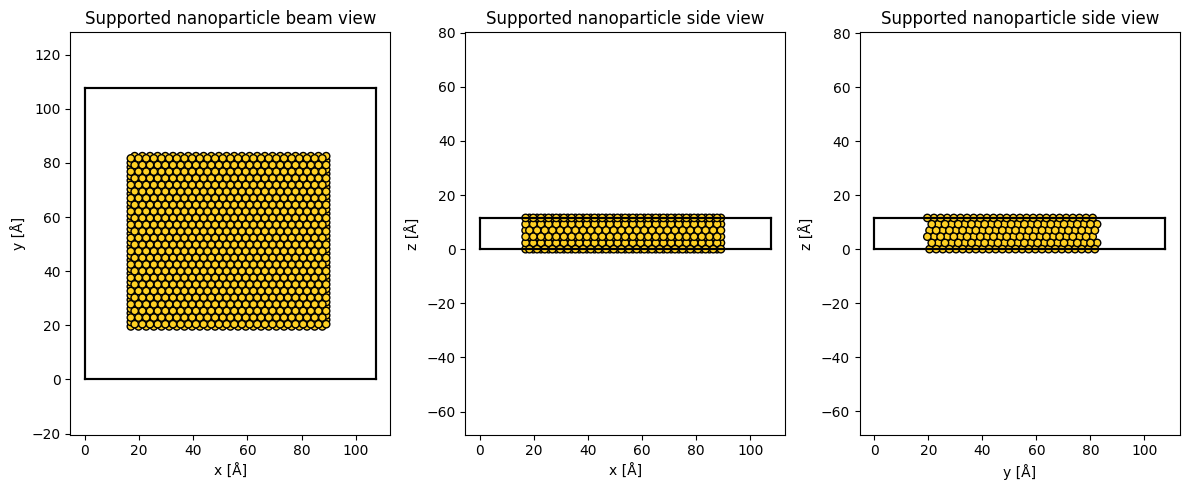

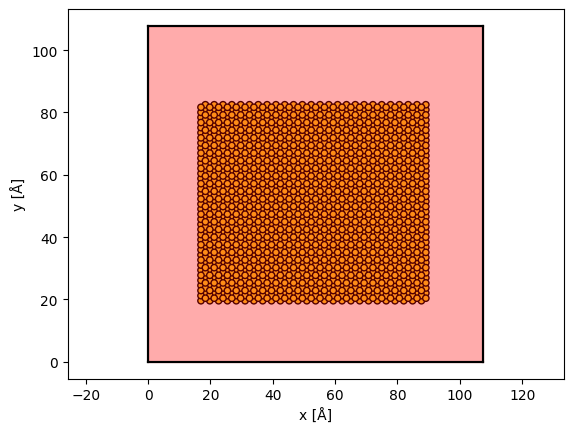

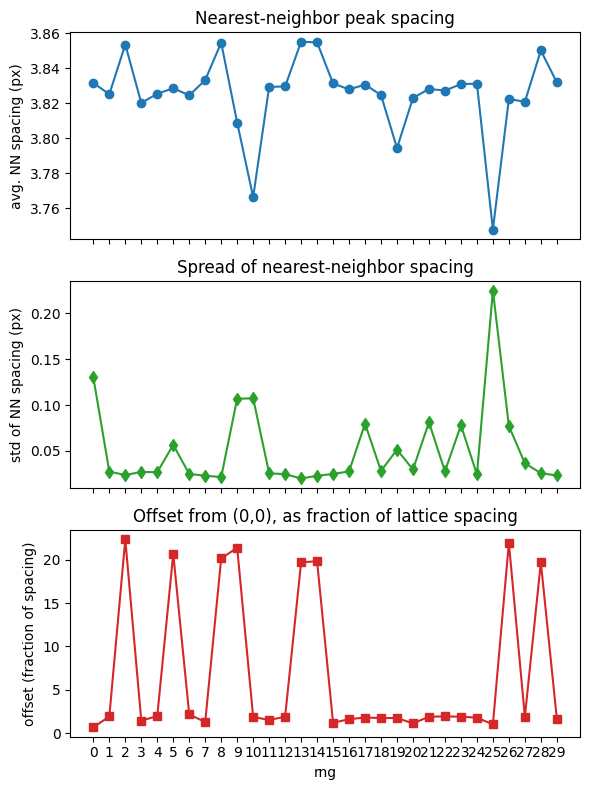

In [8]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 6
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=False,
)
# atoms *= (26,15,1)
# atoms *= (26,15,1)
atoms *= (38,22,1)

threshold = 12 * (np.sqrt(2))-0.01  # ≈ 2.121
threshold2 = 8 * (np.sqrt(2)*np.sqrt(3))-0.01  # ≈ 2.121


positions = atoms.get_positions()
mask = positions[:, 0] < threshold
del atoms[mask]
positions = atoms.get_positions()  # recompute!

mask = positions[:, 1] < threshold2
del atoms[mask]

threshold = 75 * (np.sqrt(2)) - 12*np.sqrt(2) +0.01  # ≈ 2.121
threshold2 = 43 * (np.sqrt(2)*np.sqrt(3)) - 9 * (np.sqrt(2)*np.sqrt(3)) -0.01  # ≈ 2.121


positions = atoms.get_positions()
mask = positions[:, 0] > threshold
del atoms[mask]
positions = atoms.get_positions()  # recompute!

mask = positions[:, 1] > threshold2
del atoms[mask]

atoms.center(vacuum=0.00001, axis=2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();


pot_gpts = 512
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 6

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)
start = [0,0]
end = [potential.extent[0],potential.extent[1]]
print(end)
gpts = 64

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=True
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

fig,ax = plt.subplots()
abtem.show_atoms(atoms,ax=ax)
grid_scan.add_to_plot(ax)
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()


measurement_cropped = measurement.crop(gpts=(256,256))

dose = 1e15

intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dset_6 = dataset_noisy

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
}

avg_nearest_neighbour_spacing_1 = []
avg_nearest_neighbour_spacing_m1 = []
std_nearest_neighbour_spacing_1 = []
std_nearest_neighbour_spacing_m1 = []
offset_fraction_lattice_spacing_1 = []
offset_fraction_lattice_spacing_m1 = []
std_nearest_neighbour_spacing = []
offset_fraction_lattice_spacing = []
avg_nearest_neighbour_spacing = []

pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()



# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

rng = range(30)
potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)

for i in rng:
    

    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//64,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    rng=i
    )
    for sign in [1,-1]:
        phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)
        a = normalize(potential_sub)
        c = normalize(sign * phase)
        xcorr = fftconvolve(a, c, mode='full')
        N = a.shape[0]
        center = N - 1  # zero-lag index in each dimension

        # --- step 1: find local maxima on the discrete grid ---
        neighborhood_size = 5  # adjust based on expected peak spacing/width
        local_max = (xcorr == maximum_filter(xcorr, size=neighborhood_size))

        # threshold to discard noise peaks (keep only strong ones)
        threshold = 0.3 * xcorr.max()
        peak_mask = local_max & (xcorr > threshold)

        peak_coords = np.argwhere(peak_mask)

        results = []
        for (r, c) in peak_coords:
            # skip edge pixels where parabolic interpolation would go out of bounds
            if r == 0 or r == xcorr.shape[0]-1 or c == 0 or c == xcorr.shape[1]-1:
                continue
            r_sub, c_sub = parabolic_subpixel_peak(xcorr, r, c)
            row_lag = r_sub - center
            col_lag = c_sub - center
            distance = np.hypot(row_lag, col_lag)
            angle_deg = np.degrees(np.arctan2(row_lag, col_lag))
            value = xcorr[r, c]
            results.append({
                'row_lag': row_lag,
                'col_lag': col_lag,
                'distance_px': distance,
                'angle_deg': angle_deg,
                'peak_value': value
            })

        # sort by distance from zero-lag
        results.sort(key=lambda x: x['distance_px'])

            
        nonzero_results = [r for r in results if r['distance_px'] > 1e-3]
        distances = np.array([r['distance_px'] for r in nonzero_results])

        # --- nearest-neighbor spacing between peaks (lattice periodicity) ---
        # sort all peak positions, then for each peak find distance to its nearest other peak
        positions = np.array([(r['row_lag'], r['col_lag']) for r in results])  # include (0,0) here

        nn_distances = []
        for i, pos in enumerate(positions):
            diffs = positions - pos
            dists = np.hypot(diffs[:, 0], diffs[:, 1])
            dists[i] = np.inf  # exclude self
            nn_distances.append(dists.min())

        nn_distances = np.array(nn_distances)
        avg_nn_spacing = nn_distances.mean()
        std_nn_spacing = nn_distances.std()



        # --- offset: distance from (0,0) to the closest peak ---
        closest_idx = np.argmin(distances)
        closest_peak = nonzero_results[closest_idx]
        offset_distance = closest_peak['distance_px']



        # normalized offset, as a fraction of the lattice spacing — useful single number
        # for "how misaligned are the two images relative to one lattice period"
        fractional_offset = offset_distance / avg_nn_spacing
        if sign == 1:
            avg_nearest_neighbour_spacing_1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_1.append(offset_distance)
        if sign == -1:
            avg_nearest_neighbour_spacing_m1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_m1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_m1.append(offset_distance)
    if std_nearest_neighbour_spacing_1[-1] < std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_1[-1])
    if std_nearest_neighbour_spacing_1[-1] > std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_m1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_m1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_m1[-1])


    print(avg_nearest_neighbour_spacing)
    print(std_nearest_neighbour_spacing)
    print(offset_fraction_lattice_spacing)




fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(rng, avg_nearest_neighbour_spacing, 'o-', color='tab:blue')
axes[0].set_ylabel('avg. NN spacing (px)')
axes[0].set_title('Nearest-neighbor peak spacing')

axes[1].plot(rng, std_nearest_neighbour_spacing, 'd-', color='tab:green')
axes[1].set_ylabel('std of NN spacing (px)')
axes[1].set_title('Spread of nearest-neighbor spacing')

axes[2].plot(rng, offset_fraction_lattice_spacing, 's-', color='tab:red')
axes[2].set_ylabel('offset (fraction of spacing)')
axes[2].set_xlabel('rng')
axes[2].set_title('Offset from (0,0), as fraction of lattice spacing')
axes[2].set_xticks(rng)

plt.tight_layout()
plt.show()


## finite crystal 28 mrad

[107.48023074035522, 107.77754868245982]


tasks:   0%|          | 0/82 [00:00<?, ?it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


...

[np.float64(3.8174365817242584), np.float64(3.8170177735509614), np.float64(3.816932435277477), np.float64(3.819389498730019), np.float64(3.819243132157514), np.float64(3.8168930635303275), np.float64(3.8169987459117114), np.float64(3.8192075465746607), np.float64(3.8171566474208225), np.float64(3.8175145003431776), np.float64(3.8168957731494713), np.float64(3.816718709654641), np.float64(3.816921622654912), np.float64(3.8205405157450585), np.float64(3.816685920599888), np.float64(3.816746435734688), np.float64(3.8167448760172347), np.float64(3.8189313784724015), np.float64(3.816816737875241), np.float64(3.8187405314004685), np.float64(3.8173384851531695), np.float64(3.816673634719321), np.float64(3.8186153114746024), np.float64(3.819201559142845), np.float64(3.81868207634002), np.float64(3.8194398688243654), np.float64(3.816903069149235), np.float64(3.816841648621302)]
[np.float64(0.03018396835352094), np.float64(0.03040628188446788), np.float64(0.029678479562319445), np.float64(0.083

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(3.8174365817242584), np.float64(3.8170177735509614), np.float64(3.816932435277477), np.float64(3.819389498730019), np.float64(3.819243132157514), np.float64(3.8168930635303275), np.float64(3.8169987459117114), np.float64(3.8192075465746607), np.float64(3.8171566474208225), np.float64(3.8175145003431776), np.float64(3.8168957731494713), np.float64(3.816718709654641), np.float64(3.816921622654912), np.float64(3.8205405157450585), np.float64(3.816685920599888), np.float64(3.816746435734688), np.float64(3.8167448760172347), np.float64(3.8189313784724015), np.float64(3.816816737875241), np.float64(3.8187405314004685), np.float64(3.8173384851531695), np.float64(3.816673634719321), np.float64(3.8186153114746024), np.float64(3.819201559142845), np.float64(3.81868207634002), np.float64(3.8194398688243654), np.float64(3.816903069149235), np.float64(3.816841648621302), np.float64(3.81686369057342)]
[np.float64(0.03018396835352094), np.float64(0.03040628188446788), np.float64(0.0296784

  0%|          | 0/125 [00:00<?, ?it/s]

[np.float64(3.8174365817242584), np.float64(3.8170177735509614), np.float64(3.816932435277477), np.float64(3.819389498730019), np.float64(3.819243132157514), np.float64(3.8168930635303275), np.float64(3.8169987459117114), np.float64(3.8192075465746607), np.float64(3.8171566474208225), np.float64(3.8175145003431776), np.float64(3.8168957731494713), np.float64(3.816718709654641), np.float64(3.816921622654912), np.float64(3.8205405157450585), np.float64(3.816685920599888), np.float64(3.816746435734688), np.float64(3.8167448760172347), np.float64(3.8189313784724015), np.float64(3.816816737875241), np.float64(3.8187405314004685), np.float64(3.8173384851531695), np.float64(3.816673634719321), np.float64(3.8186153114746024), np.float64(3.819201559142845), np.float64(3.81868207634002), np.float64(3.8194398688243654), np.float64(3.816903069149235), np.float64(3.816841648621302), np.float64(3.81686369057342), np.float64(3.8171420901367132)]
[np.float64(0.03018396835352094), np.float64(0.03040628

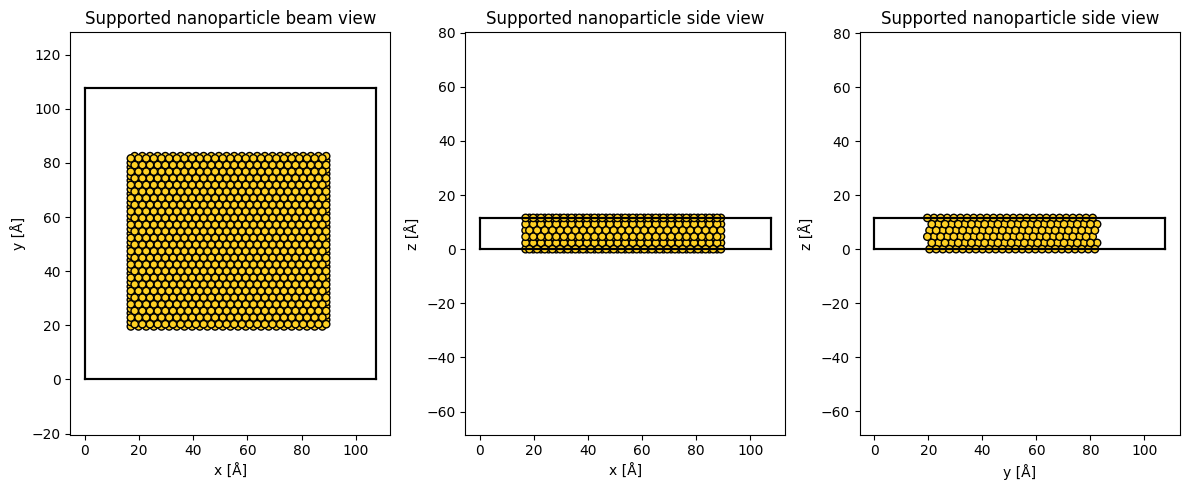

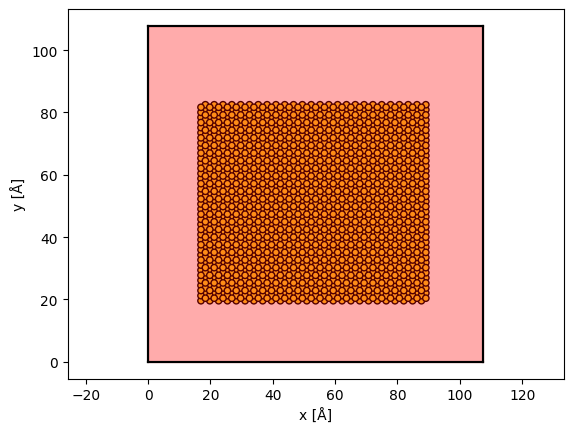

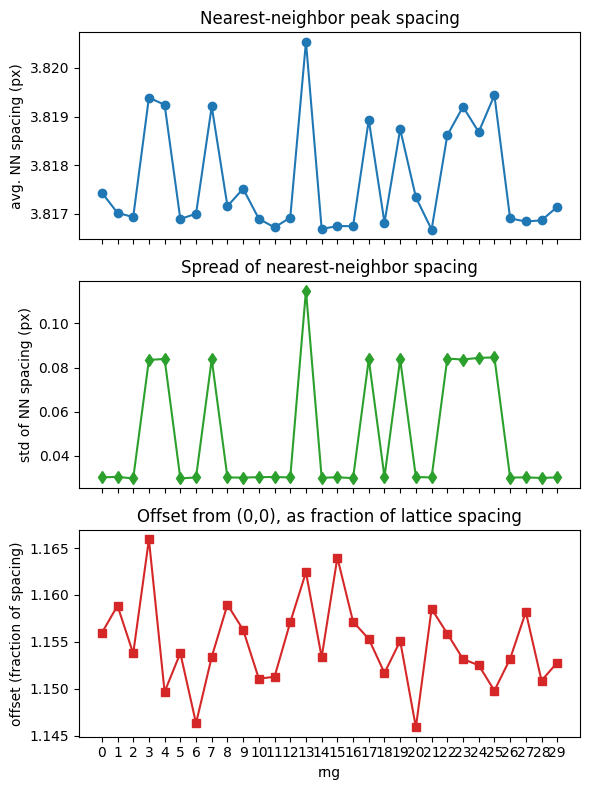

In [9]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 6
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=False,
)
# atoms *= (26,15,1)
# atoms *= (26,15,1)
atoms *= (38,22,1)

threshold = 12 * (np.sqrt(2))-0.01  # ≈ 2.121
threshold2 = 8 * (np.sqrt(2)*np.sqrt(3))-0.01  # ≈ 2.121


positions = atoms.get_positions()
mask = positions[:, 0] < threshold
del atoms[mask]
positions = atoms.get_positions()  # recompute!

mask = positions[:, 1] < threshold2
del atoms[mask]

threshold = 75 * (np.sqrt(2)) - 12*np.sqrt(2) +0.01  # ≈ 2.121
threshold2 = 43 * (np.sqrt(2)*np.sqrt(3)) - 9 * (np.sqrt(2)*np.sqrt(3)) -0.01  # ≈ 2.121


positions = atoms.get_positions()
mask = positions[:, 0] > threshold
del atoms[mask]
positions = atoms.get_positions()  # recompute!

mask = positions[:, 1] > threshold2
del atoms[mask]

atoms.center(vacuum=0.00001, axis=2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();


pot_gpts = 512
# pot_gpts = 16384
potential = abtem.Potential(
    atoms,
    gpts=(pot_gpts, pot_gpts),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 28

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)
start = [0,0]
end = [potential.extent[0],potential.extent[1]]
print(end)
gpts = 64

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=True
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

fig,ax = plt.subplots()
abtem.show_atoms(atoms,ax=ax)
grid_scan.add_to_plot(ax)
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()


measurement_cropped = measurement.crop(gpts=(256,256))

dose = 1e15

intensity_measurement_noisy = measurement_cropped.poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dset_6 = dataset_noisy

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

def normalize(img):
    img = img.astype(np.float64)
    img -= img.mean()
    norm = np.linalg.norm(img)
    return img / norm if norm > 0 else img

def parabolic_subpixel_peak(corr, r, c):
    def subpixel_1d(f_minus, f_0, f_plus):
        denom = (f_minus - 2*f_0 + f_plus)
        if denom == 0:
            return 0.0
        return 0.5 * (f_minus - f_plus) / denom
    dr = subpixel_1d(corr[r-1, c], corr[r, c], corr[r+1, c])
    dc = subpixel_1d(corr[r, c-1], corr[r, c], corr[r, c+1])
    return r + dr, c + dc

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
}

avg_nearest_neighbour_spacing_1 = []
avg_nearest_neighbour_spacing_m1 = []
std_nearest_neighbour_spacing_1 = []
std_nearest_neighbour_spacing_m1 = []
offset_fraction_lattice_spacing_1 = []
offset_fraction_lattice_spacing_m1 = []
std_nearest_neighbour_spacing = []
offset_fraction_lattice_spacing = []
avg_nearest_neighbour_spacing = []

pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()



# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

rng = range(30)
potential_sub = zoom(potential.array[0::1].sum(0), 0.5, order=3)

for i in rng:
    

    ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//64,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    rng=i
    )
    for sign in [1,-1]:
        phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)
        a = normalize(potential_sub)
        c = normalize(sign * phase)
        xcorr = fftconvolve(a, c, mode='full')
        N = a.shape[0]
        center = N - 1  # zero-lag index in each dimension

        # --- step 1: find local maxima on the discrete grid ---
        neighborhood_size = 5  # adjust based on expected peak spacing/width
        local_max = (xcorr == maximum_filter(xcorr, size=neighborhood_size))

        # threshold to discard noise peaks (keep only strong ones)
        threshold = 0.3 * xcorr.max()
        peak_mask = local_max & (xcorr > threshold)

        peak_coords = np.argwhere(peak_mask)

        results = []
        for (r, c) in peak_coords:
            # skip edge pixels where parabolic interpolation would go out of bounds
            if r == 0 or r == xcorr.shape[0]-1 or c == 0 or c == xcorr.shape[1]-1:
                continue
            r_sub, c_sub = parabolic_subpixel_peak(xcorr, r, c)
            row_lag = r_sub - center
            col_lag = c_sub - center
            distance = np.hypot(row_lag, col_lag)
            angle_deg = np.degrees(np.arctan2(row_lag, col_lag))
            value = xcorr[r, c]
            results.append({
                'row_lag': row_lag,
                'col_lag': col_lag,
                'distance_px': distance,
                'angle_deg': angle_deg,
                'peak_value': value
            })

        # sort by distance from zero-lag
        results.sort(key=lambda x: x['distance_px'])

            
        nonzero_results = [r for r in results if r['distance_px'] > 1e-3]
        distances = np.array([r['distance_px'] for r in nonzero_results])

        # --- nearest-neighbor spacing between peaks (lattice periodicity) ---
        # sort all peak positions, then for each peak find distance to its nearest other peak
        positions = np.array([(r['row_lag'], r['col_lag']) for r in results])  # include (0,0) here

        nn_distances = []
        for i, pos in enumerate(positions):
            diffs = positions - pos
            dists = np.hypot(diffs[:, 0], diffs[:, 1])
            dists[i] = np.inf  # exclude self
            nn_distances.append(dists.min())

        nn_distances = np.array(nn_distances)
        avg_nn_spacing = nn_distances.mean()
        std_nn_spacing = nn_distances.std()



        # --- offset: distance from (0,0) to the closest peak ---
        closest_idx = np.argmin(distances)
        closest_peak = nonzero_results[closest_idx]
        offset_distance = closest_peak['distance_px']



        # normalized offset, as a fraction of the lattice spacing — useful single number
        # for "how misaligned are the two images relative to one lattice period"
        fractional_offset = offset_distance / avg_nn_spacing
        if sign == 1:
            avg_nearest_neighbour_spacing_1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_1.append(offset_distance)
        if sign == -1:
            avg_nearest_neighbour_spacing_m1.append(avg_nn_spacing)
            std_nearest_neighbour_spacing_m1.append(std_nn_spacing)
            offset_fraction_lattice_spacing_m1.append(offset_distance)
    if std_nearest_neighbour_spacing_1[-1] < std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_1[-1])
    if std_nearest_neighbour_spacing_1[-1] > std_nearest_neighbour_spacing_m1[-1]:
        avg_nearest_neighbour_spacing.append(avg_nearest_neighbour_spacing_m1[-1])
        std_nearest_neighbour_spacing.append(std_nearest_neighbour_spacing_m1[-1])
        offset_fraction_lattice_spacing.append(offset_fraction_lattice_spacing_m1[-1])


    print(avg_nearest_neighbour_spacing)
    print(std_nearest_neighbour_spacing)
    print(offset_fraction_lattice_spacing)




fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axes[0].plot(rng, avg_nearest_neighbour_spacing, 'o-', color='tab:blue')
axes[0].set_ylabel('avg. NN spacing (px)')
axes[0].set_title('Nearest-neighbor peak spacing')

axes[1].plot(rng, std_nearest_neighbour_spacing, 'd-', color='tab:green')
axes[1].set_ylabel('std of NN spacing (px)')
axes[1].set_title('Spread of nearest-neighbor spacing')

axes[2].plot(rng, offset_fraction_lattice_spacing, 's-', color='tab:red')
axes[2].set_ylabel('offset (fraction of spacing)')
axes[2].set_xlabel('rng')
axes[2].set_title('Offset from (0,0), as fraction of lattice spacing')
axes[2].set_xticks(rng)

plt.tight_layout()
plt.show()
